# Notebook 05 — PLS-DA and SVM Training

**CMSC 190 Special Problem**  
Classification of High-Protein and Low-Protein Corn (*Zea Mays*) Using NIR Spectral Data and Machine Learning Techniques

---

This notebook trains and evaluates two classical machine learning models on the augmented NIR spectral dataset:

1. **PLS-DA** (Partial Least Squares Discriminant Analysis) — a chemometric baseline
2. **SVM** (Support Vector Machine with RBF kernel) — a powerful kernel-based classifier

Both models are evaluated on the held-out test set and saved to `saved_models/` for use in notebook 07.

---
## Section 1 — Imports and Setup

This cell imports all the Python libraries and custom functions we need for this notebook.  
We also set a clean visual style for plots and fix `random_state = 42` so that results are reproducible — running the notebook twice will always give the same output.

In [9]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline

from src.trainer import evaluate_model, plot_confusion_matrix, save_model

# ── Visual style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Fix random seed for reproducibility
random_state = 42
np.random.seed(random_state)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Section 2 — Load Augmented Training and Test Data

Here we load the four NumPy arrays produced by notebook 04.  
- `X_train` and `y_train` are the **augmented training set** — they include both the original samples and the synthetically generated ones.
- `X_test` and `y_test` are the **held-out test set** — these samples were never seen during training or augmentation.

> **Important:** `X_test` and `y_test` will **only** be used at the very end of each section for final model evaluation. They will never be used for training, cross-validation, or hyperparameter tuning.

In [10]:
X_train = np.load('../data/processed/X_train_augmented.npy')
y_train = np.load('../data/processed/y_train_augmented.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_test  = np.load('../data/processed/y_test.npy')

print('Array shapes:')
print(f'  X_train : {X_train.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_test  : {y_test.shape}')

print('\nClass distribution in y_train:')
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique_train, counts_train):
    label = 'High Protein (1)' if cls == 1 else 'Low Protein  (0)'
    print(f'  {label} : {cnt} samples')

print('\nClass distribution in y_test:')
unique_test, counts_test = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique_test, counts_test):
    label = 'High Protein (1)' if cls == 1 else 'Low Protein  (0)'
    print(f'  {label} : {cnt} samples')

Array shapes:
  X_train : (2000, 700)
  y_train : (2000,)
  X_test  : (16, 700)
  y_test  : (16,)

Class distribution in y_train:
  Low Protein  (0) : 1012 samples
  High Protein (1) : 988 samples

Class distribution in y_test:
  Low Protein  (0) : 8 samples
  High Protein (1) : 8 samples


> **Reminder:** `X_test` and `y_test` are frozen from this point onward. They will not be altered, scaled separately for cross-validation, or used in any fitting step. Their only role is final model evaluation.

---
## Section 3 — PLS-DA Model

**What is PLS-DA?**

PLS-DA stands for **Partial Least Squares Discriminant Analysis**. It is a classical chemometric method that is widely used in NIR spectroscopy research. It works by finding a small set of *latent variables* (components) that capture the directions of maximum covariance between the spectral features and the class labels.

PLS-DA is especially well-suited for spectral data because:
- NIR datasets are **high-dimensional** (700 wavelength channels) but contain relatively few samples.
- Adjacent wavelength channels are **highly collinear** (correlated), which causes ordinary linear classifiers to struggle.
- PLS reduces this collinearity by projecting the data onto a small number of uncorrelated components.

**Implementation note:** scikit-learn does not include a native PLS-DA class. Instead, we use `PLSRegression` — which performs the same latent-variable decomposition — and adapt it for binary classification by **thresholding** its continuous output at 0.5: values ≥ 0.5 are predicted as class 1 (High Protein) and values < 0.5 are predicted as class 0 (Low Protein).

**Choosing the number of components:** Too few components underfit the data; too many overfit it. We determine the optimal number using **10-fold cross-validation** on the training set, selecting the value that maximises the mean F1 score.

### 3a — PLS-DA Cross-Validation: Finding the Optimal Number of Components

We test every number of components from 1 to 20 and evaluate each using 10-fold cross-validation on the training set.  
The F1 score is used because it balances precision and recall, which is important for our binary classification task.  
We then plot the results to visually identify the best number of components.

Running 10-fold CV for PLS-DA (n_components = 1 to 20)...
  n_components =  1  |  mean F1 = 0.4790
  n_components =  2  |  mean F1 = 0.4530
  n_components =  3  |  mean F1 = 0.7059
  n_components =  4  |  mean F1 = 0.7780
  n_components =  5  |  mean F1 = 0.8000
  n_components =  6  |  mean F1 = 0.8120
  n_components =  7  |  mean F1 = 0.8047
  n_components =  8  |  mean F1 = 0.8256
  n_components =  9  |  mean F1 = 0.8305
  n_components = 10  |  mean F1 = 0.8358
  n_components = 11  |  mean F1 = 0.8344
  n_components = 12  |  mean F1 = 0.8444
  n_components = 13  |  mean F1 = 0.8543
  n_components = 14  |  mean F1 = 0.8661
  n_components = 15  |  mean F1 = 0.8881
  n_components = 16  |  mean F1 = 0.8944
  n_components = 17  |  mean F1 = 0.9068
  n_components = 18  |  mean F1 = 0.9133
  n_components = 19  |  mean F1 = 0.9306
  n_components = 20  |  mean F1 = 0.9391

Optimal number of components: 20
Best mean cross-validation F1: 0.9391


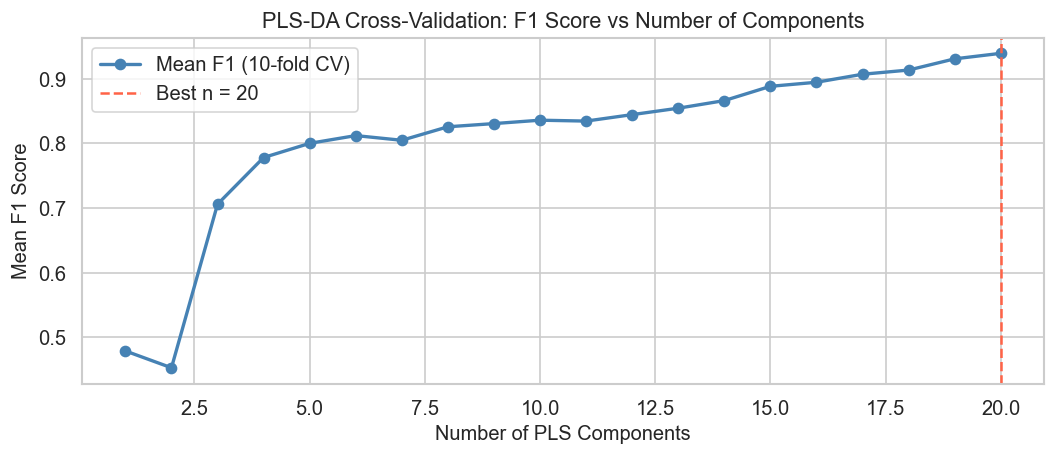

In [11]:
# ── Wrapper class so that PLSRegression works inside cross_val_score ──────────
# cross_val_score expects a classifier with .predict() returning integer labels.
# This thin wrapper thresholds the continuous PLS output at 0.5.
from sklearn.base import BaseEstimator, ClassifierMixin

class PLSDAClassifier(BaseEstimator, ClassifierMixin):
    """Thin sklearn-compatible wrapper that turns PLSRegression into a binary classifier."""

    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X, y):
        self.pls_ = PLSRegression(n_components=self.n_components)
        self.pls_.fit(X, y)
        return self

    def predict(self, X):
        y_cont = self.pls_.predict(X).ravel()
        return (y_cont >= 0.5).astype(int)


# ── Cross-validation loop ─────────────────────────────────────────────────────
n_components_range = range(1, 21)
mean_f1_scores = []

print('Running 10-fold CV for PLS-DA (n_components = 1 to 20)...')
for n in n_components_range:
    pls_cv = PLSDAClassifier(n_components=n)
    scores = cross_val_score(pls_cv, X_train, y_train, cv=10, scoring='f1')
    mean_f1_scores.append(scores.mean())
    print(f'  n_components = {n:2d}  |  mean F1 = {scores.mean():.4f}')

best_n_components = list(n_components_range)[int(np.argmax(mean_f1_scores))]
print(f'\nOptimal number of components: {best_n_components}')
print(f'Best mean cross-validation F1: {max(mean_f1_scores):.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(n_components_range), mean_f1_scores, marker='o', linewidth=2,
        color='steelblue', label='Mean F1 (10-fold CV)')
ax.axvline(best_n_components, color='tomato', linestyle='--',
           label=f'Best n = {best_n_components}')
ax.set_xlabel('Number of PLS Components', fontsize=12)
ax.set_ylabel('Mean F1 Score', fontsize=12)
ax.set_title('PLS-DA Cross-Validation: F1 Score vs Number of Components', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


### 3b — Train Final PLS-DA Model and Evaluate on Test Set

Using the best number of components found above, we now train the final PLS-DA model on the **entire training set**.  
We then generate predictions on the held-out test set, compute performance metrics, plot the confusion matrix, and save the trained model to disk.

In [12]:
# ── Train final PLS-DA model ──────────────────────────────────────────────────
pls_model = PLSRegression(n_components=best_n_components)
pls_model.fit(X_train, y_train)
print(f'PLS-DA trained with n_components = {best_n_components}.')

# ── Generate predictions (threshold continuous output at 0.5) ─────────────────
y_pred_plsda = (pls_model.predict(X_test).ravel() >= 0.5).astype(int)
print(f'Predictions generated: {y_pred_plsda.shape[0]} samples.')


PLS-DA trained with n_components = 20.
Predictions generated: 16 samples.


> **Technical note:** `evaluate_model` in `src/trainer.py` calls `model.predict()` internally. Because PLS-DA requires a custom thresholding step, we compute the predictions manually above and use a small adapter below to pass them to `evaluate_model` and `plot_confusion_matrix`.


  Evaluation Results — PLS-DA
  Accuracy  : 0.8125
  Precision : 0.7778
  Recall    : 0.8750
  F1-Score  : 0.8235



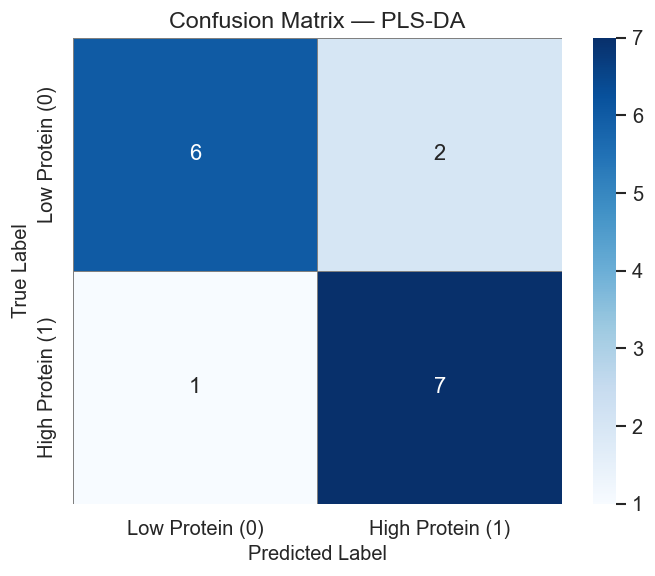

Model saved to: ../saved_models/pls_da_best.pkl


In [13]:
# ── Adapter: wrap pre-computed predictions so evaluate_model works cleanly ────
class _PrecomputedPredictor:
    """Minimal wrapper that returns a fixed array from .predict(), used to
    pass pre-thresholded PLS-DA predictions into evaluate_model()."""
    def __init__(self, y_pred):
        self._y_pred = y_pred
    def predict(self, X):
        return self._y_pred

pls_adapter = _PrecomputedPredictor(y_pred_plsda)

results_plsda = evaluate_model(pls_adapter, X_test, y_test, model_name='PLS-DA')

# ── Confusion matrix ──────────────────────────────────────────────────────────
plot_confusion_matrix(y_test, y_pred_plsda, model_name='PLS-DA')

# ── Save model ────────────────────────────────────────────────────────────────
save_model(pls_model, '../saved_models/pls_da_best.pkl')

---
## Section 4 — SVM Model

**What is an SVM?**

A **Support Vector Machine (SVM)** with an RBF (Radial Basis Function) kernel is a powerful non-linear classifier. It works by finding the decision boundary (hyperplane) in a transformed feature space that maximises the margin between the two classes. SVMs tend to generalise well even with small sample sizes.

**Why StandardScaler?**  
SVMs are sensitive to the absolute scale of input features. If one feature has values in the thousands and another in the hundredths, the SVM's distance calculations will be dominated by the larger feature. `StandardScaler` normalises each wavelength channel to zero mean and unit variance, giving all features equal weight.

> **Data leakage prevention:** The scaler is fitted **only on the training data** and then applied to both the training and test sets. Fitting on the test set (or on the full dataset) would allow test-set information to influence the model — a form of data leakage that inflates performance estimates.

**Hyperparameter tuning:**  
The two most important SVM hyperparameters are:
- `C` — the regularisation strength (higher C = less regularisation, tighter fit)
- `gamma` — the kernel bandwidth (controls how far the influence of a single training sample reaches)

We find the best combination using `GridSearchCV` with 10-fold cross-validation.

### 4a — Scale the Data

We fit `StandardScaler` on `X_train` only, then use it to transform both `X_train` and `X_test`.  
The fitted scaler is also saved to disk because it must be applied to any new spectrum at inference time — the same transformation used during training must be reproduced exactly.

In [14]:
# ── Fit scaler on training data only ─────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train)

# ── Transform both splits ─────────────────────────────────────────────────────
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train_scaled shape : {X_train_scaled.shape}')
print(f'X_test_scaled  shape : {X_test_scaled.shape}')
print(f'\nX_train_scaled mean (first channel): {X_train_scaled[:, 0].mean():.6f}  (should be ~0)')
print(f'X_train_scaled std  (first channel): {X_train_scaled[:, 0].std():.6f}  (should be ~1)')

# ── Save the scaler so it can be reused at inference time ─────────────────────
import os
os.makedirs('../saved_models', exist_ok=True)
joblib.dump(scaler, '../saved_models/svm_scaler.pkl')
print('\nScaler saved to: ../saved_models/svm_scaler.pkl')

X_train_scaled shape : (2000, 700)
X_test_scaled  shape : (16, 700)

X_train_scaled mean (first channel): -0.000000  (should be ~0)
X_train_scaled std  (first channel): 1.000000  (should be ~1)

Scaler saved to: ../saved_models/svm_scaler.pkl


### 4b — SVM Hyperparameter Tuning with GridSearchCV

We define a grid of candidate values for `C` and `gamma` and use `GridSearchCV` to exhaustively try all combinations.  
Each combination is scored using 10-fold cross-validation on the **scaled training set**, and the combination with the highest mean F1 score is selected.  
`n_jobs=-1` tells scikit-learn to use all available CPU cores, which speeds up the search significantly.

In [15]:
param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf'],
}

grid_search = GridSearchCV(
    SVC(random_state=random_state),
    param_grid,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)

print('Running GridSearchCV for SVM (this may take a moment)...')
grid_search.fit(X_train_scaled, y_train)

print(f'\nBest parameters     : {grid_search.best_params_}')
print(f'Best CV F1 score    : {grid_search.best_score_:.4f}')

Running GridSearchCV for SVM (this may take a moment)...
Fitting 10 folds for each of 16 candidates, totalling 160 fits

Best parameters     : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV F1 score    : 0.9137


### 4c — Train Final SVM Model and Evaluate on Test Set

Using the best hyperparameters found by `GridSearchCV`, we re-train the SVM on the full scaled training set.  
We then evaluate it on the held-out scaled test set (`X_test_scaled`) and save the trained model.

SVM trained with best parameters.

  Evaluation Results — SVM
  Accuracy  : 0.8125
  Precision : 0.8571
  Recall    : 0.7500
  F1-Score  : 0.8000



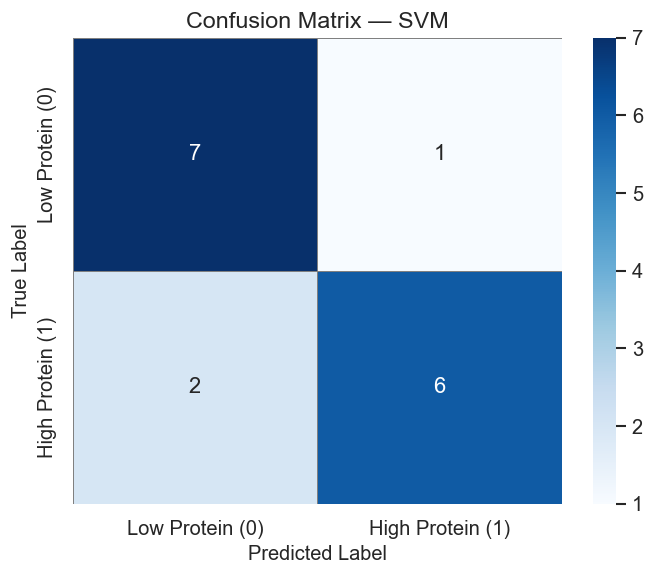

Model saved to: ../saved_models/svm_best.pkl


In [16]:
# ── Train final SVM with best hyperparameters ─────────────────────────────────
best_params = grid_search.best_params_
svm_model = SVC(
    C=best_params['C'],
    gamma=best_params['gamma'],
    kernel=best_params['kernel'],
    random_state=random_state,
)
svm_model.fit(X_train_scaled, y_train)
print('SVM trained with best parameters.')

# ── Generate predictions on the scaled test set ───────────────────────────────
y_pred_svm = svm_model.predict(X_test_scaled)

# ── Evaluate ──────────────────────────────────────────────────────────────────
results_svm = evaluate_model(svm_model, X_test_scaled, y_test, model_name='SVM')

# ── Confusion matrix ──────────────────────────────────────────────────────────
plot_confusion_matrix(y_test, y_pred_svm, model_name='SVM')

# ── Save model ────────────────────────────────────────────────────────────────
save_model(svm_model, '../saved_models/svm_best.pkl')

---
## Section 5 — Compare PLS-DA vs SVM

Now that both models have been evaluated on the test set, we bring their results together into a single summary table and a grouped bar chart.  
This side-by-side comparison makes it easy to see which model performed better across all four metrics and by how much.

In [17]:
# ── Build summary DataFrame ───────────────────────────────────────────────────
summary_df = pd.DataFrame([
    {
        'Model':     results_plsda['model_name'],
        'Accuracy':  results_plsda['accuracy'],
        'Precision': results_plsda['precision'],
        'Recall':    results_plsda['recall'],
        'F1-Score':  results_plsda['f1_score'],
    },
    {
        'Model':     results_svm['model_name'],
        'Accuracy':  results_svm['accuracy'],
        'Precision': results_svm['precision'],
        'Recall':    results_svm['recall'],
        'F1-Score':  results_svm['f1_score'],
    },
])

summary_df = summary_df.set_index('Model')
display(summary_df.style.format('{:.4f}').background_gradient(cmap='Blues', axis=1))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
PLS-DA,0.8125,0.7778,0.8750,0.8235
SVM,0.8125,0.8571,0.7500,0.8000


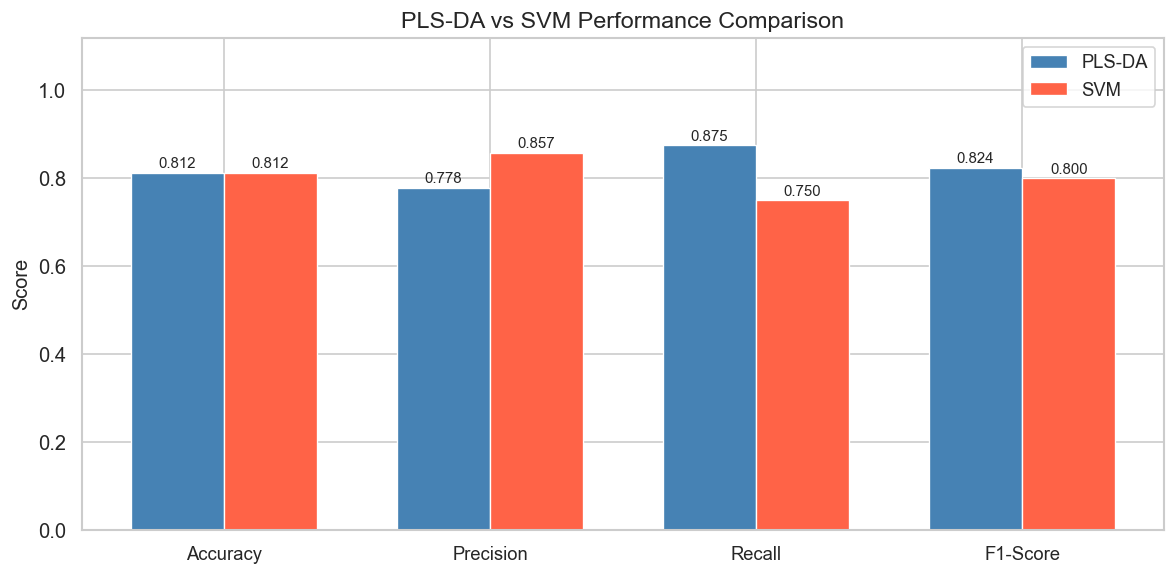

In [18]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models      = summary_df.index.tolist()
x           = np.arange(len(metrics))
bar_width   = 0.35
colors      = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(10, 5))

for i, (model_name, color) in enumerate(zip(models, colors)):
    values = summary_df.loc[model_name, metrics].values
    bars = ax.bar(x + i * bar_width, values, bar_width,
                  label=model_name, color=color, edgecolor='white', linewidth=0.8)
    # Annotate bar tops
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9,
        )

ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('PLS-DA vs SVM Performance Comparison', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Interpretation

Comparing the two models:

- **PLS-DA** is the classical chemometric baseline. It works well because it is specifically designed for high-dimensional, collinear spectral data and requires no feature scaling.
- **SVM** is generally expected to achieve high accuracy on spectral data after proper normalisation, owing to its ability to find a non-linear decision boundary through the RBF kernel.

The model with the higher **F1-Score** on the test set is considered the stronger performer for this dataset, since F1 balances both precision (avoiding false positives) and recall (avoiding false negatives) — both of which matter in a grain quality classification context.

> The exact winning model will depend on the results above. Both models will be compared again against the 1D-CNN in notebook 07.

---
## Section 6 — Summary

This notebook completed the following steps:

### Models Trained
| Model | Method |
|-------|--------|
| **PLS-DA** | `PLSRegression` adapted for binary classification via 0.5 thresholding |
| **SVM** | `SVC` with RBF kernel, trained on `StandardScaler`-normalised features |

### Hyperparameter Selection
- **PLS-DA** — Optimal number of latent components determined by 10-fold cross-validation over the range 1–20, selecting the value that maximised mean F1 score.
- **SVM** — Best `C` and `gamma` values found by `GridSearchCV` with 10-fold cross-validation over a 4 × 4 parameter grid.

### Data Handling Notes
- `X_test` and `y_test` were **never** used during training or tuning — only for final evaluation.
- The `StandardScaler` was fitted on `X_train` only to prevent data leakage.
- No additional augmentation or preprocessing was applied in this notebook.

### Performance Metrics Reported
Accuracy · Precision · Recall · F1-Score (all using scikit-learn with `average='binary'`)

### Saved Outputs
| File | Contents |
|------|----------|
| `saved_models/pls_da_best.pkl` | Trained `PLSRegression` model |
| `saved_models/svm_best.pkl` | Trained `SVC` model (best hyperparameters) |
| `saved_models/svm_scaler.pkl` | Fitted `StandardScaler` for SVM inference |

### What Comes Next
- **Notebook 06** (`06_cnn_training.ipynb`) will train a **1D Convolutional Neural Network** on the same spectral data.
- **Notebook 07** (`07_model_comparison.ipynb`) will reload all three saved models and perform a final head-to-head comparison across all evaluation metrics.